# **Aplica mascaramento de nuvens e calcula o NDVI para o satélite Sentinel-2**

O Sentinel-2 é uma missão de imageamento multiespectral de alta resolução e ampla cobertura que subsidia os estudos de monitoramento terrestre da Copernicus, incluindo o monitoramento da vegetação, do solo e da cobertura hídrica, bem como a observação de vias navegáveis e zonas costeiras.

- Exemplo retirado de: https://www.youtube.com/watch?v=1YeT_EH2U54
- Dados utilizados: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED?hl=pt-br
- Dados de probabilidade de nuvens: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_CLOUD_PROBABILITY

# Instalando Xee e inicializando GEE

Se você tiver uma conta do Earth Engine você poderá encontrar a sua ID de um projeto do GEE acessando https://code.earthengine.google.com/ com sua conta google, e depois verificando do lado superior direito do Code Editor o nome da sua ID.

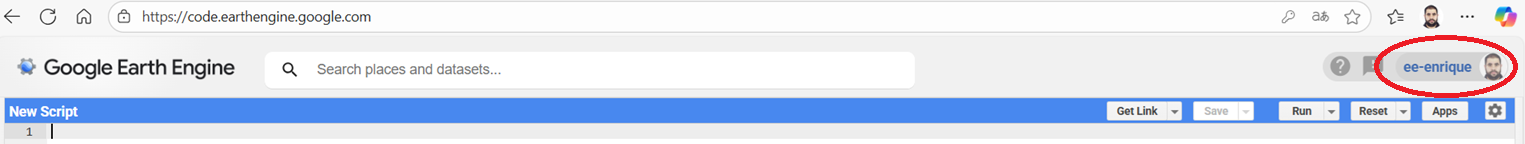

Insira a sua ID no campo `geemap.ee_initialize(project='SUA ID')`.

In [1]:
# instalando Xee
!pip install -q xee

# importa bibliotecas
import ee
import geemap
import xee
import xarray as xr

# inicializando pelo GEE
geemap.ee_initialize(project='ee-enrique', opt_url='https://earthengine-highvolume.googleapis.com')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.5 MB/s eta 0:00:00


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


# Selecionando uma região

In [2]:
Map = geemap.Map(basemap = 'SATELLITE')
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

Selecione um polígono na imagem interativa acima

In [3]:
#  estrai as coordenadas da região selecionada
roi = Map.draw_last_feature.geometry()

In [4]:
# mostra as coordenadas
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          -38.40499,
                          -10.720211
                        ],
                        [
                          -38.404319,
                          -10.719172
                        ],
                        [
                          -38.402324,
                          -10.719916
                        ],
                        [
                          -38.403069,
                          -10.720875
                        ],
                        [
                          -38.40499,
                          -10.720211
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

# Carregando os dados, aplicando o mascaramento de nuvens e calculando o NDVI

- Dados utilizados: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED?hl=pt-br
- Dados de probabilidade de nuvens: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_CLOUD_PROBABILITY
- São imagens a cada 5 dias do Sentinel 2.

O NDVI é calculado através da seguinte equação:

NDVI = (R0.8 - R0.6) / (R0.8 + R0.6). Em que: R0.8 é a banda do NIR e R0.6 é a banda do vermelho.


Aplicando para as bandas do Sentinel-2 temos que:


NDVI = (B8 - B4) / (B8 + B4)

 - B8 = 835,1 nm - NIR
 - B4 = 664,5 nm - Vermelho

In [5]:
# carregando os dados
sen2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").linkCollection(ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY"), 'probability') \
         .filterDate('2024', '2025') \
         .filterBounds(roi)
sen2

In [6]:
# criando uma função que aplica o mascaramento de nuvens e calcula o NDVI
def cloud_mask(img):

    # aplica mascara de nuvens
    qa = img.select('probability')
    cloud_mask = qa.lt(20)  # todas as imagens com porcentagem menor que 20% de cobertura de nuvens

    # calculando NDVI
    ms = img.select('B.*').multiply(0.0001) # seleciona todas as bandas começando com "B" e aplica fator de escala
    ndvi = ms.normalizedDifference(['B8','B4']).rename('ndvi')

    return ndvi.updateMask(cloud_mask).copyProperties(img, ['system:time_start'])

In [7]:
# carregando os dados com a aplicação da máscara de nuvens
sen2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").linkCollection(ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY"), 'probability') \
         .filterDate('2024', '2025') \
         .filterBounds(roi) \
         .map(cloud_mask)
sen2

Propriedades da imagem antes de aplicar a máscara de nuvens e calcular o NDVI. Repare que temos todas as bandas da imagem.

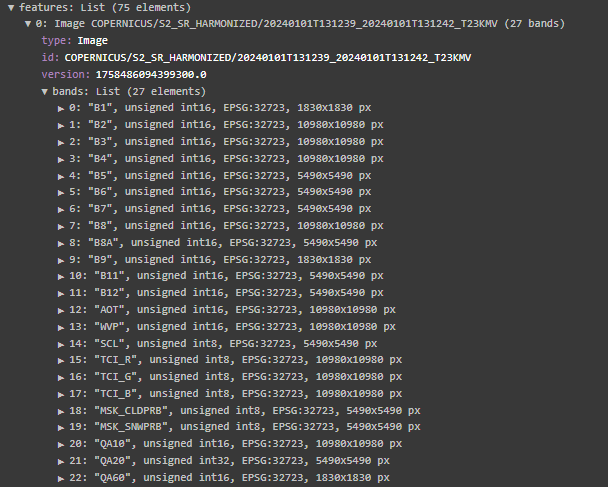

Repare que agora a banda dos dados tem apenas as informações da variável NDVI.

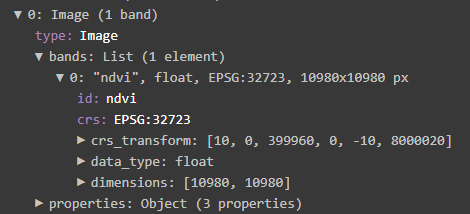

# Transformando as imagens para o formato do dataset do xarray

O atributo escala é a resolução espacial em graus. As bandas B4 e B8 do Sentinel-2 tem 10 m de resolução espacial. Em km corresponde a 0.01 km. Para transformar de km para graus dividimos por 100, ou seja, 0.01/100 = 0.0001 graus.

- `10 m = 0.0001 graus`





In [8]:
# transformando os dados para dataset do xarray
ds = xr.open_dataset(sen2,
                     engine = 'ee',
                     crs = 'EPSG:4326',
                     geometry = roi,
                     scale = 0.0001)

In [9]:
# mostrando os dados
ds

<xarray.Dataset> Size: 137kB
Dimensions:  (time: 74, lon: 27, lat: 17)
Coordinates:
  * time     (time) datetime64[ns] 592B 2024-01-05T12:55:00.106000 ... 2024-1...
  * lon      (lon) float64 216B -38.4 -38.4 -38.4 -38.4 ... -38.4 -38.4 -38.4
  * lat      (lat) float64 136B -10.72 -10.72 -10.72 ... -10.72 -10.72 -10.72
Data variables:
    ndvi     (time, lon, lat) float32 136kB ...
Attributes: (12/18)
    date_range:             [1490659200000, 1647907200000]
    description:            <p>Sentinel-2 is a wide-swath, high-resolution, m...
    keywords:               ['copernicus', 'esa', 'eu', 'msi', 'reflectance',...
    period:                 0
    product_tags:           ['msi', 'sr', 'reflectance']
    provider:               European Union/ESA/Copernicus
    ...                     ...
    type_name:              ImageCollection
    visualization_0_bands:  B4,B3,B2
    visualization_0_max:    3000.0
    visualization_0_min:    0.0
    visualization_0_name:   RGB
    crs:                    EPSG:4326

In [10]:
# essa multiplicação por "1" aumenta a velocidade de processamento. Não muda nada nos dados
ds = ds.sortby('time') * 1

In [11]:
# mostrando os dados
ds

<xarray.Dataset> Size: 137kB
Dimensions:  (time: 74, lon: 27, lat: 17)
Coordinates:
  * time     (time) datetime64[ns] 592B 2024-01-05T12:55:00.106000 ... 2024-1...
  * lon      (lon) float64 216B -38.4 -38.4 -38.4 -38.4 ... -38.4 -38.4 -38.4
  * lat      (lat) float64 136B -10.72 -10.72 -10.72 ... -10.72 -10.72 -10.72
Data variables:
    ndvi     (time, lon, lat) float32 136kB nan nan nan ... 0.1899 0.1778 0.19
Attributes: (12/18)
    date_range:             [1490659200000, 1647907200000]
    description:            <p>Sentinel-2 is a wide-swath, high-resolution, m...
    keywords:               ['copernicus', 'esa', 'eu', 'msi', 'reflectance',...
    period:                 0
    product_tags:           ['msi', 'sr', 'reflectance']
    provider:               European Union/ESA/Copernicus
    ...                     ...
    type_name:              ImageCollection
    visualization_0_bands:  B4,B3,B2
    visualization_0_max:    3000.0
    visualization_0_min:    0.0
    visualization_0_name:   RGB
    crs:                    EPSG:4326

# Plotando gráficos



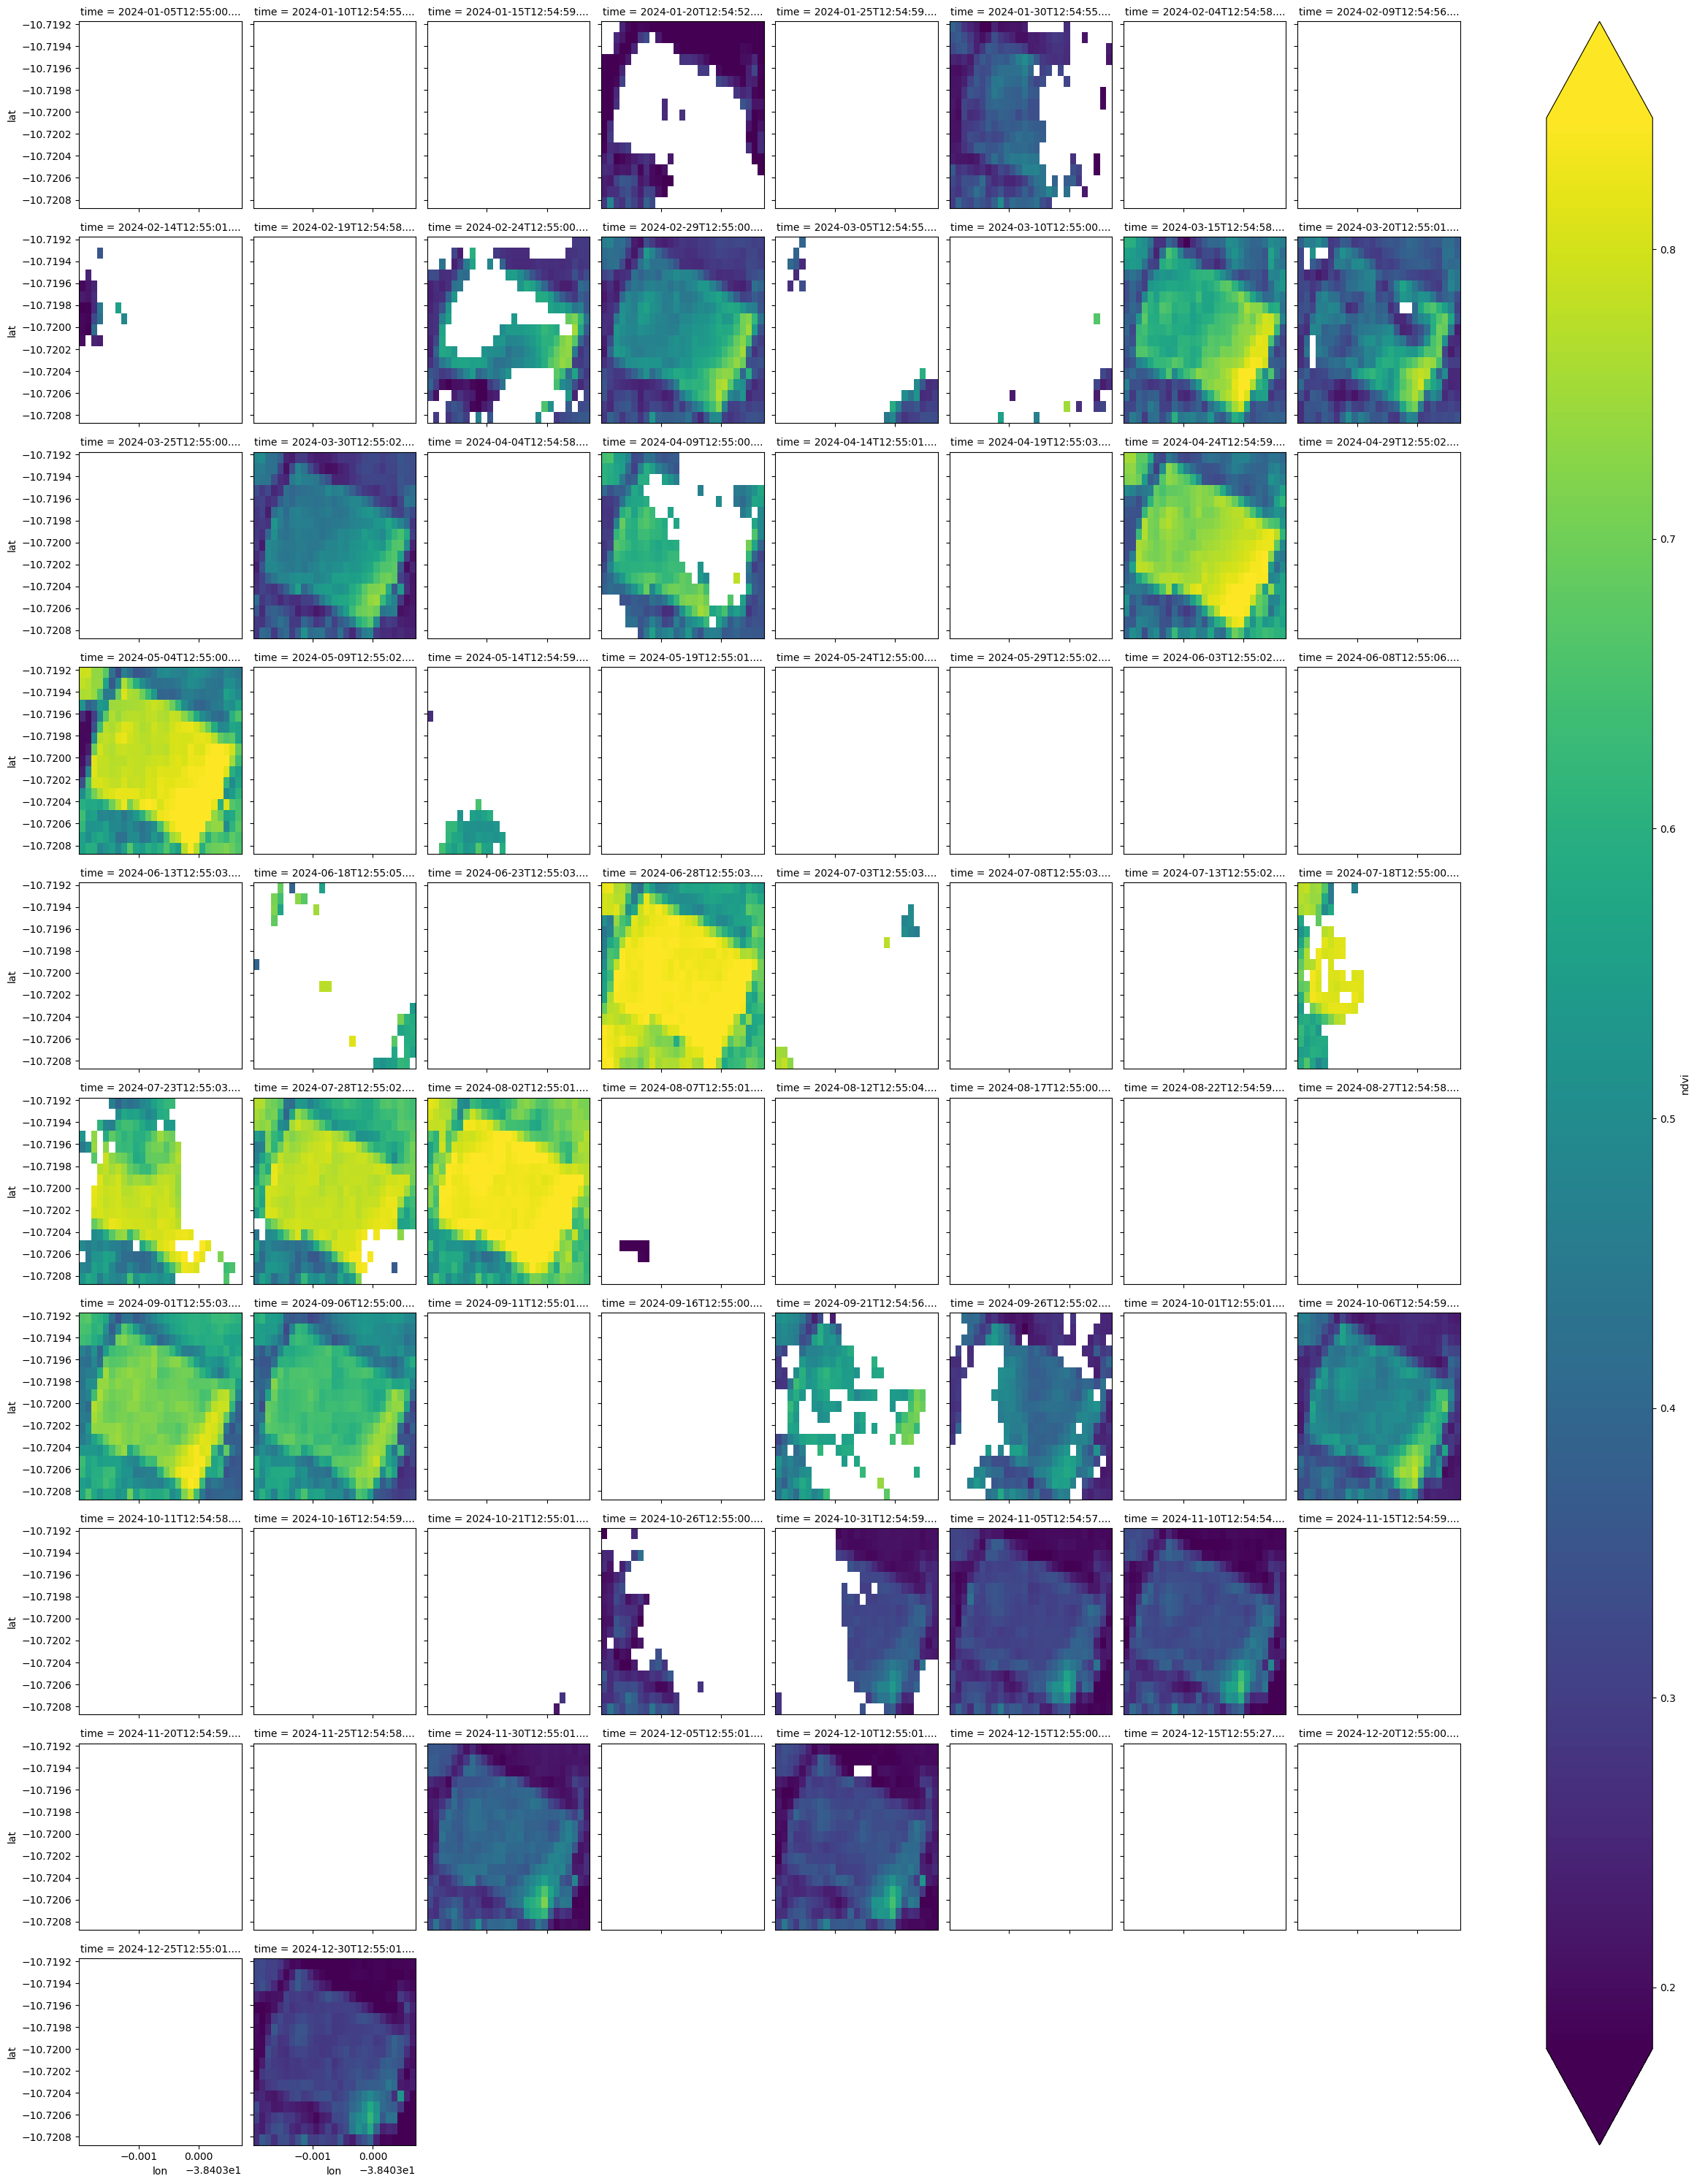

In [21]:
# gráfico. Plotando todas as imagens da coleção. Lembre-se são imagens do Sentinel-2 de 2024, a cada 5 dias.
ds.ndvi.plot(x = 'lon',
             y = 'lat',
             col = 'time',
             col_wrap = 8,
             robust = True)

Os espaços em branco nas imagens, são os locais que ocorreram nuvens.

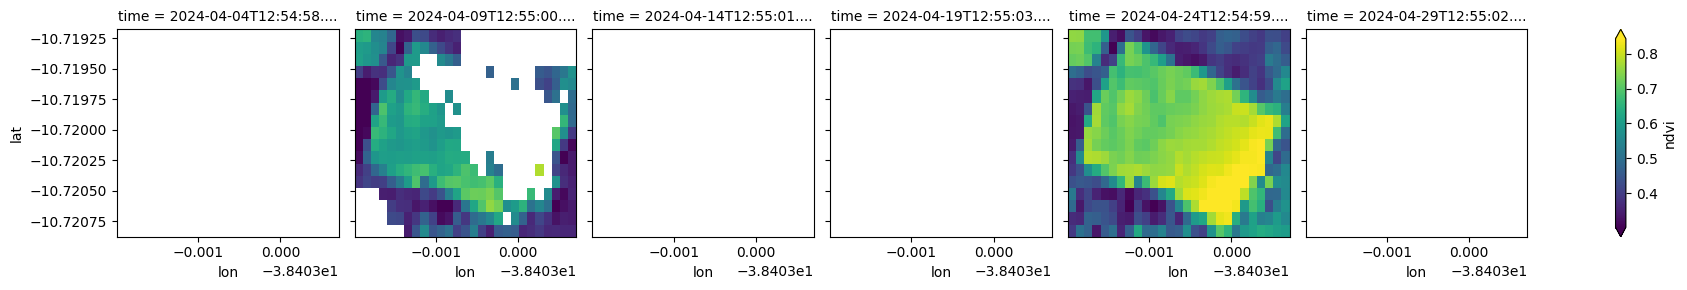

In [13]:
# gráfico. Selecionando apenas as imagens do mês de Abril
ds.sel(time = ds.time.dt.month == 4).ndvi.plot(x = 'lon',
                                               y = 'lat',
                                               col = 'time',
                                               col_wrap = 6,
                                               robust = True)

In [14]:
# Os dados estão a cada 5 dias. Iremos converter o conjunto de dados para intervalo semanal. Ou seja, teremos 50 imagens por ano.
# Assim reduziremos os dados para uma frequência temporal menor, ou seja, de a cada 5 dias para semanal (7 dias). Iremos clacular o valor "médio" semanal.
ds_weekly = ds.resample(time = 'W').mean('time')

In [15]:
# mostrando o dados semanal
ds_weekly

<xarray.Dataset> Size: 98kB
Dimensions:  (time: 53, lon: 27, lat: 17)
Coordinates:
  * lon      (lon) float64 216B -38.4 -38.4 -38.4 -38.4 ... -38.4 -38.4 -38.4
  * lat      (lat) float64 136B -10.72 -10.72 -10.72 ... -10.72 -10.72 -10.72
  * time     (time) datetime64[ns] 424B 2024-01-07 2024-01-14 ... 2025-01-05
Data variables:
    ndvi     (time, lon, lat) float32 97kB nan nan nan ... 0.1899 0.1778 0.19
Attributes: (12/18)
    date_range:             [1490659200000, 1647907200000]
    description:            <p>Sentinel-2 is a wide-swath, high-resolution, m...
    keywords:               ['copernicus', 'esa', 'eu', 'msi', 'reflectance',...
    period:                 0
    product_tags:           ['msi', 'sr', 'reflectance']
    provider:               European Union/ESA/Copernicus
    ...                     ...
    type_name:              ImageCollection
    visualization_0_bands:  B4,B3,B2
    visualization_0_max:    3000.0
    visualization_0_min:    0.0
    visualization_0_name:   RGB
    crs:                    EPSG:4326

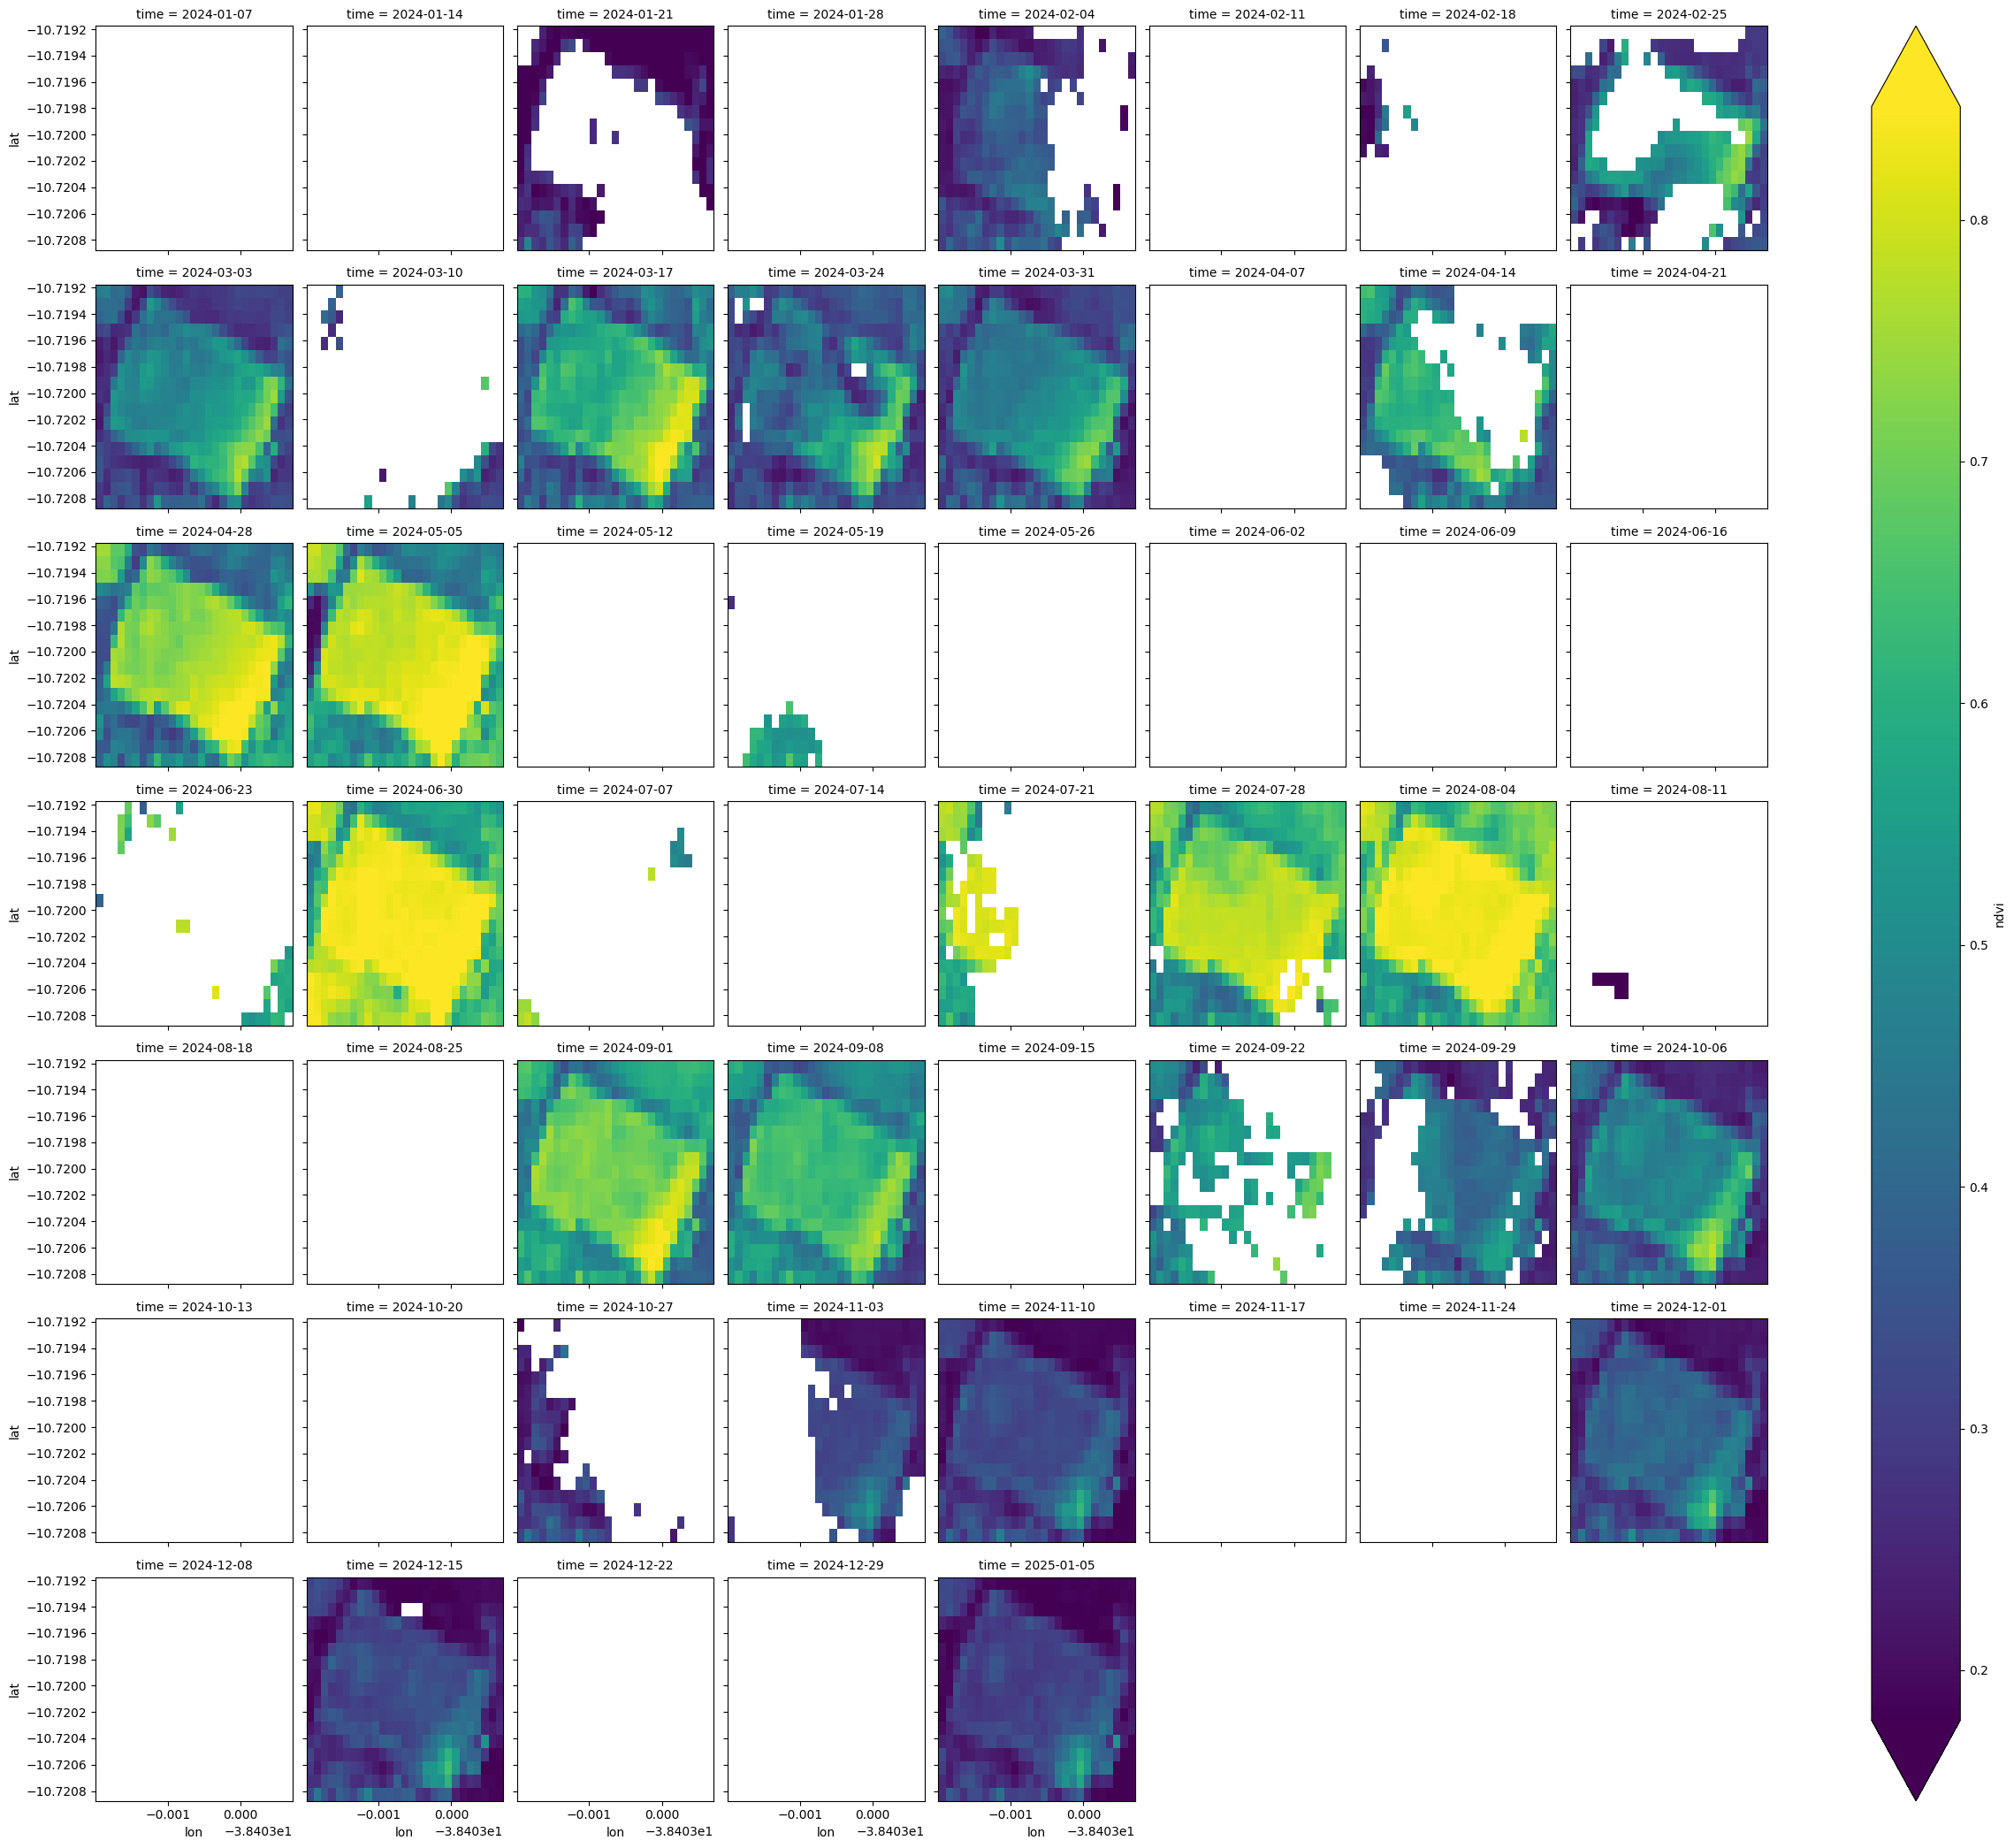

In [16]:
# plota as imagens semanais do valor médio
ds_weekly.ndvi.plot(x = 'lon',
                    y = 'lat',
                    col = 'time',
                    col_wrap = 8,
                    robust = True)

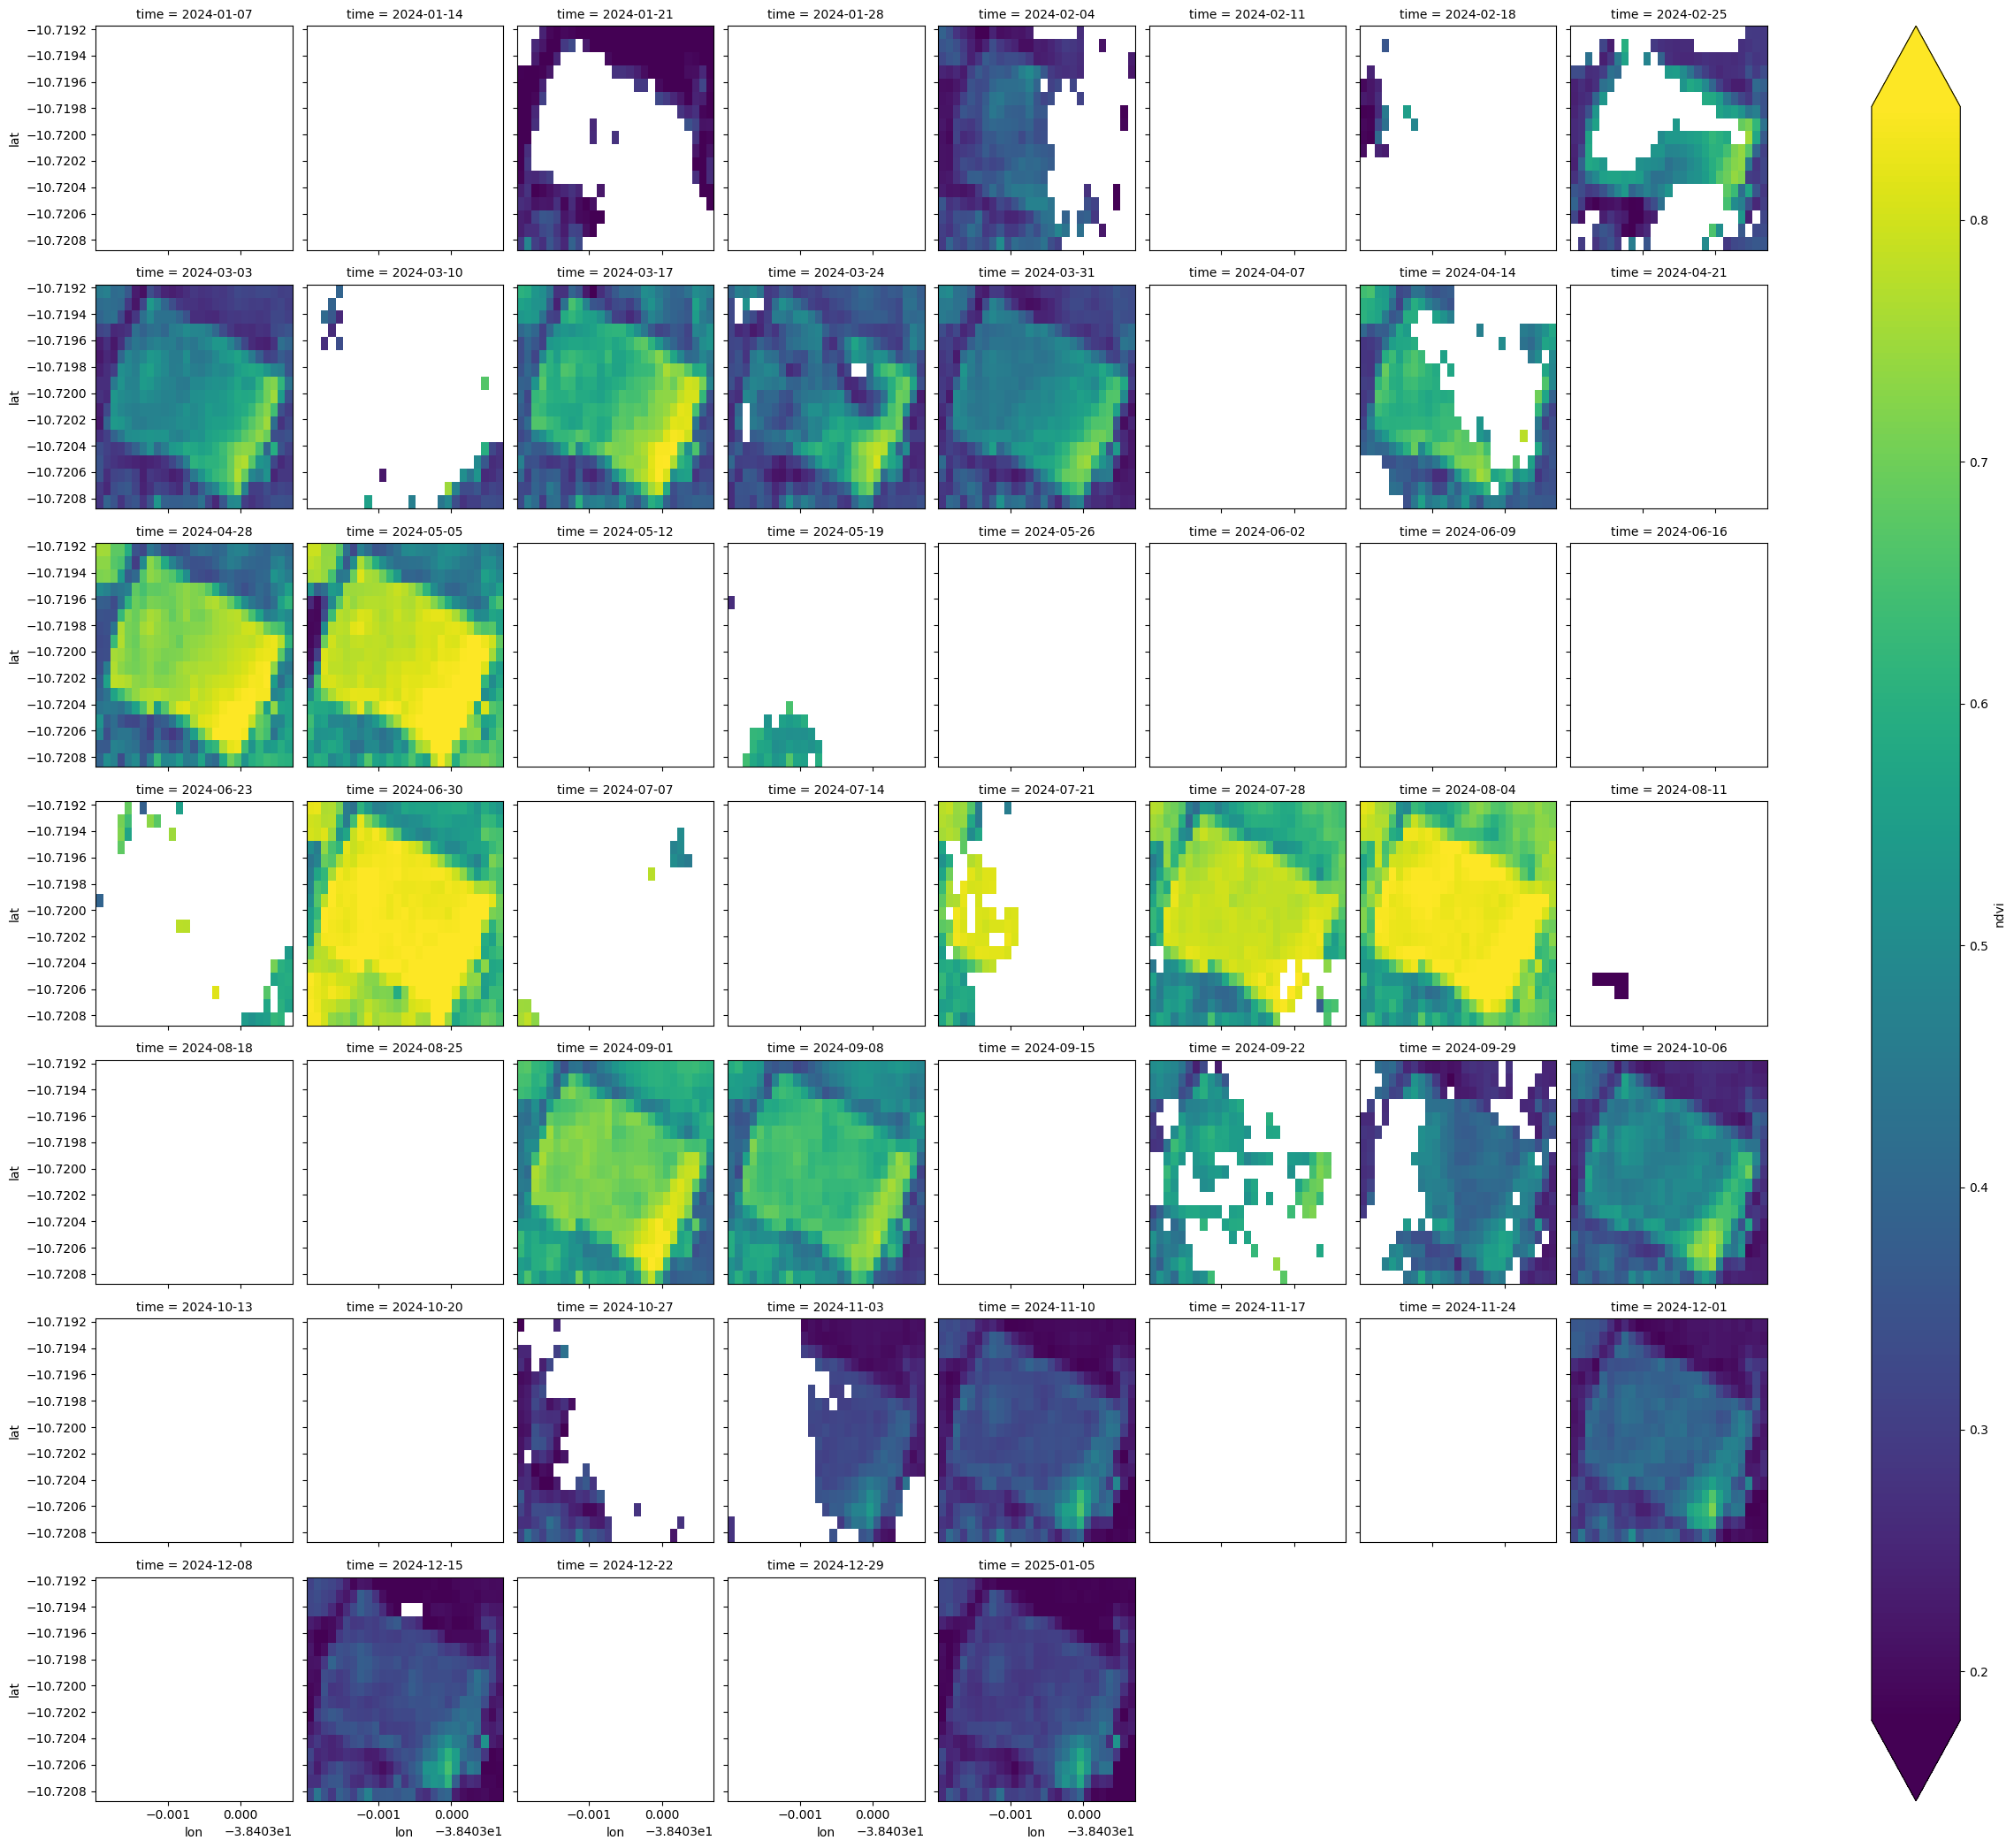

In [17]:
# usando o valor máximo semanal
ds_weekly = ds.resample(time = 'W').max('time')

# plota as imagens semanais
ds_weekly.ndvi.plot(x = 'lon',
                    y = 'lat',
                    col = 'time',
                    col_wrap = 8,
                    robust = True)

Na maioria das imagens ainda estão faltando dados de NDVI devido a ocorrência de nuvens. Então além de usar o valor médio ou máximo, como fizemos anteriormente, podemos tentar uma terceira forma para minimizar os buracos em branco nas imagens devido a ocorrência de nuvens. Podemos aplicar a técnica de `média móvel` para preencher as lacunas. Essa técnica é muito útil para reduzir a quantidade de cobertura de nuvens nas imagens.

O parâmetro time = 10 indica que a janela da média móvel é de 10 unidades de tempo, e como o dataset é semanal, mas a variável de tempo é tratada como dias (time), isso sugere que a dimensão temporal está em dias. Ou seja, a média a cada 10 dias.

Além disso, o uso de center = True indica que a média móvel é centralizada, o que é comum em séries temporais com unidades de tempo como dias.

In [18]:
# aplicando a média móvel de 10 dias
ds_rol = ds_weekly.rolling(time = 10, min_periods = 1, center = True).mean('time')

In [19]:
# mostrando os dados
ds_rol

<xarray.Dataset> Size: 98kB
Dimensions:  (lon: 27, lat: 17, time: 53)
Coordinates:
  * lon      (lon) float64 216B -38.4 -38.4 -38.4 -38.4 ... -38.4 -38.4 -38.4
  * lat      (lat) float64 136B -10.72 -10.72 -10.72 ... -10.72 -10.72 -10.72
  * time     (time) datetime64[ns] 424B 2024-01-07 2024-01-14 ... 2025-01-05
Data variables:
    ndvi     (time, lon, lat) float32 97kB 0.2937 0.2707 ... 0.1948 0.2035
Attributes: (12/18)
    date_range:             [1490659200000, 1647907200000]
    description:            <p>Sentinel-2 is a wide-swath, high-resolution, m...
    keywords:               ['copernicus', 'esa', 'eu', 'msi', 'reflectance',...
    period:                 0
    product_tags:           ['msi', 'sr', 'reflectance']
    provider:               European Union/ESA/Copernicus
    ...                     ...
    type_name:              ImageCollection
    visualization_0_bands:  B4,B3,B2
    visualization_0_max:    3000.0
    visualization_0_min:    0.0
    visualization_0_name:   RGB
    crs:                    EPSG:4326

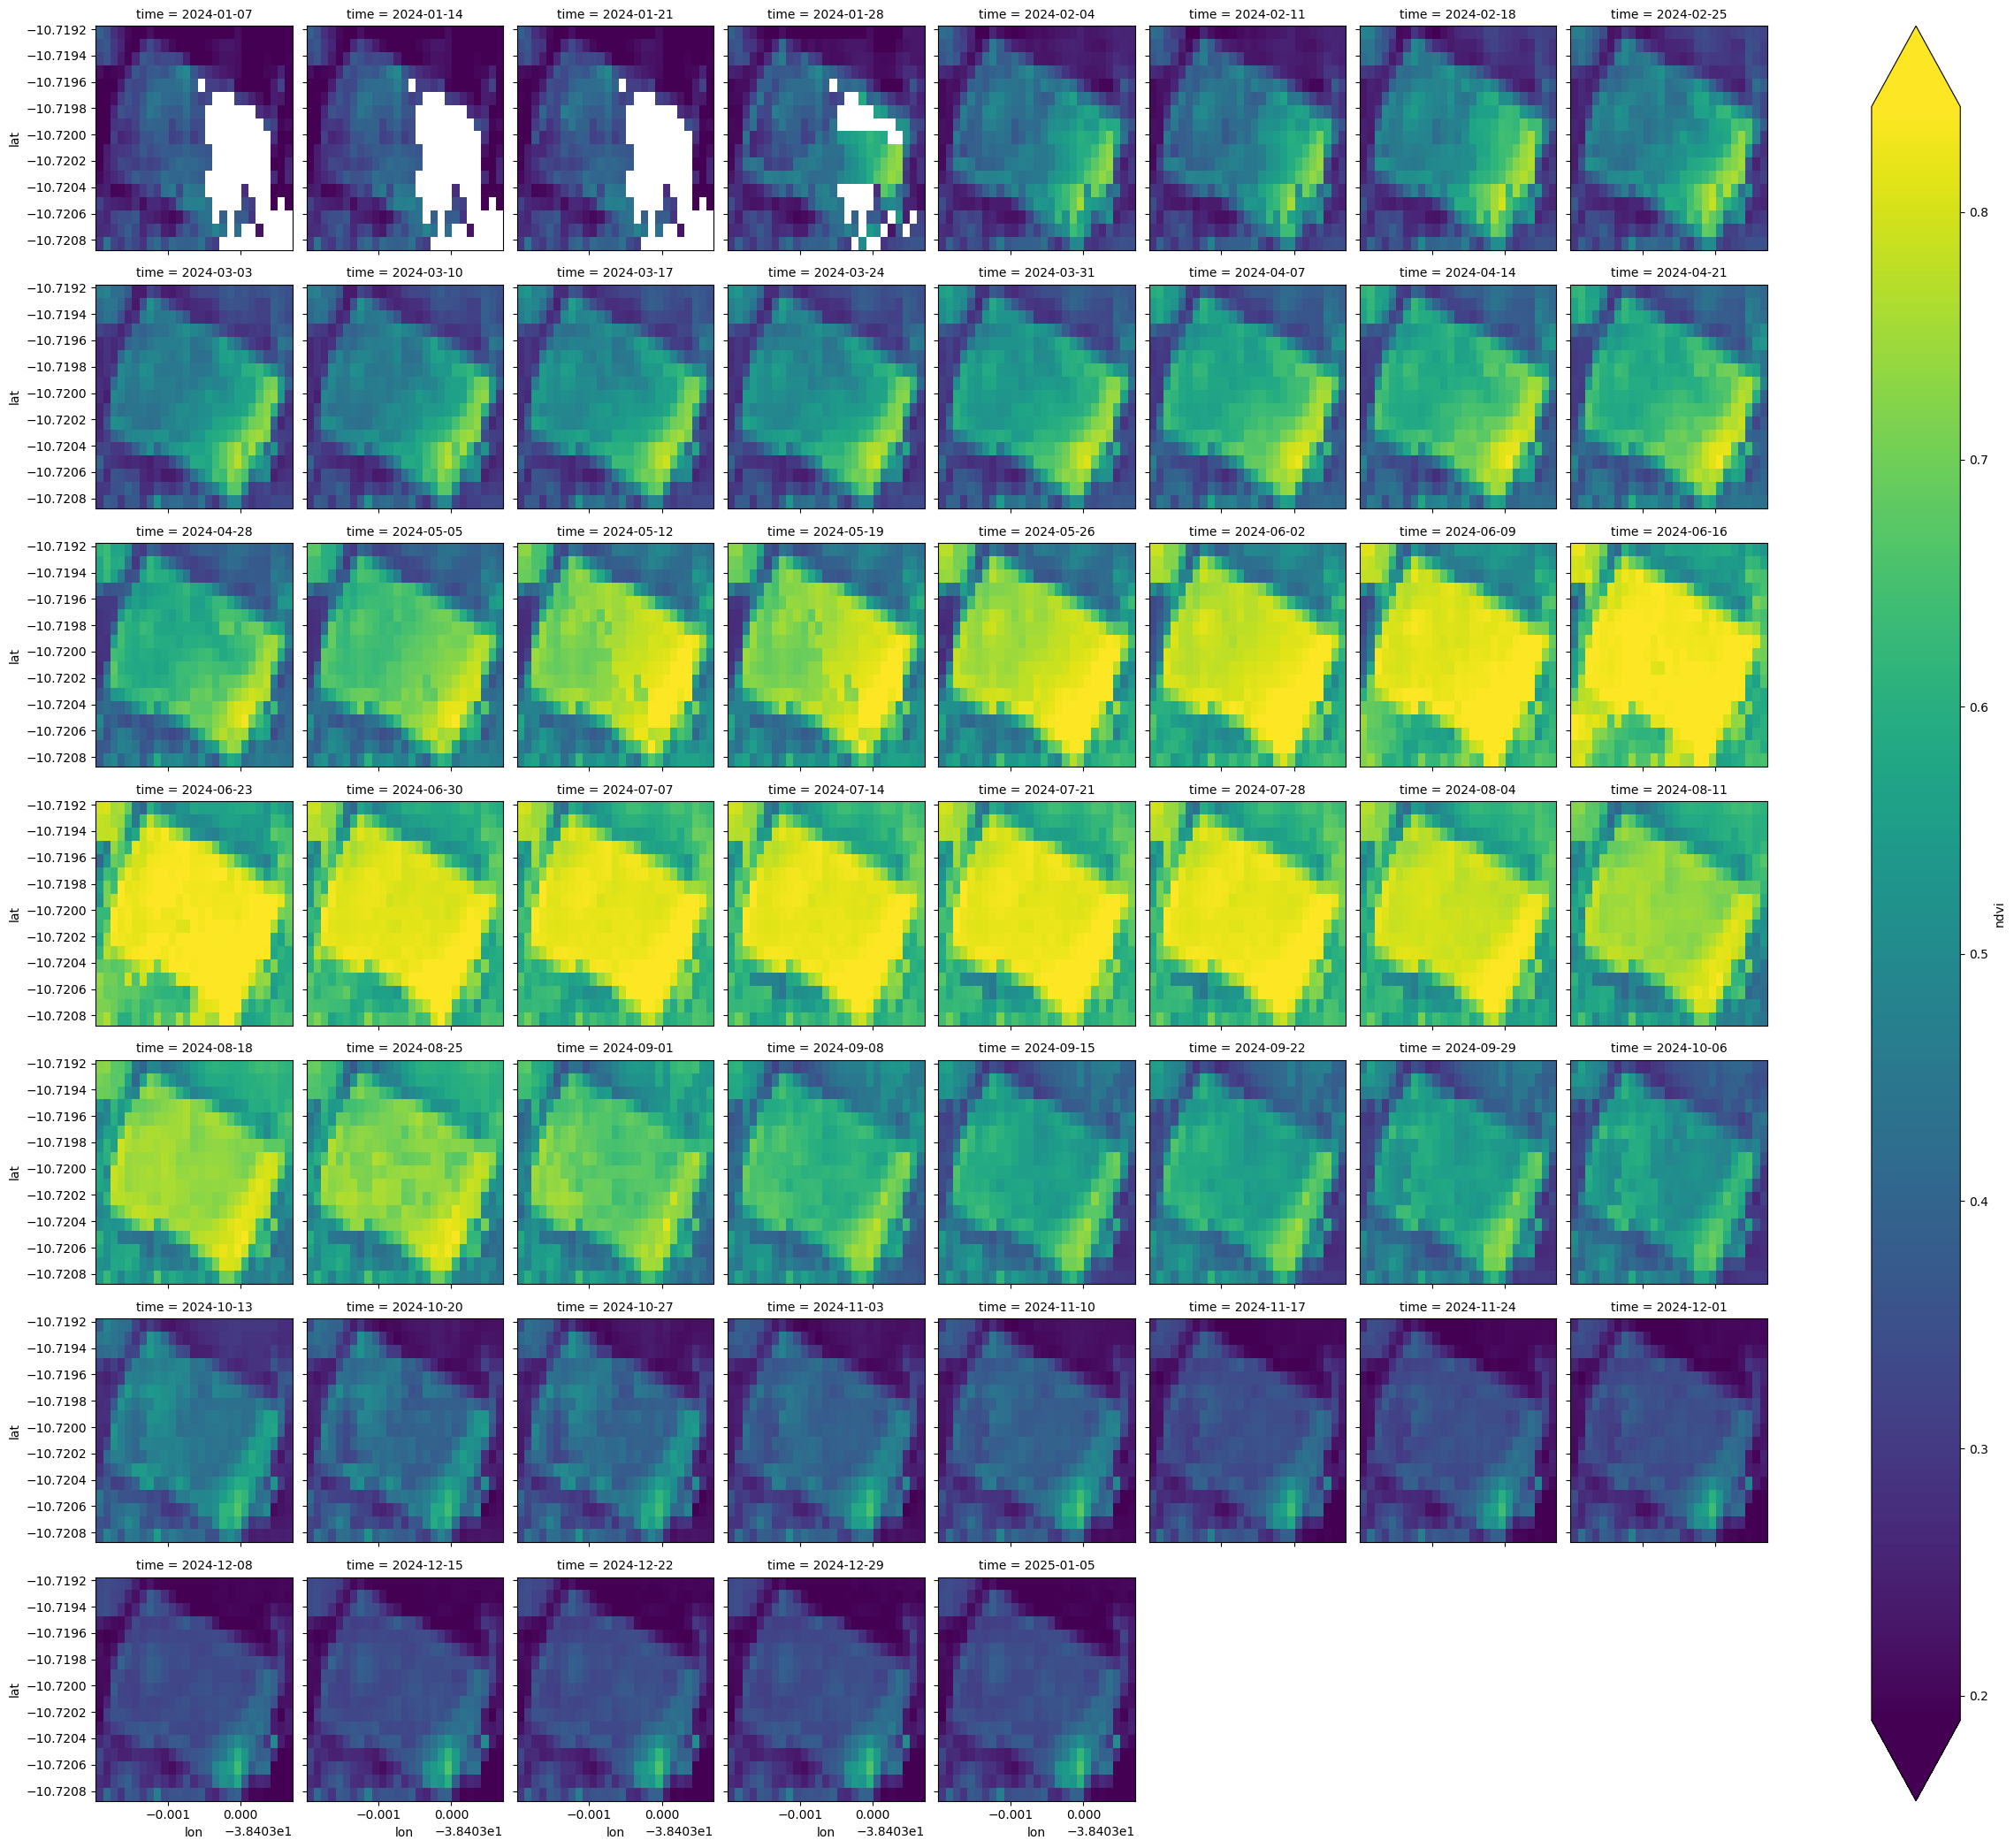

In [20]:
# plotando a figura de média móvel de 10 dias
ds_rol.ndvi.plot(x = 'lon',
                 y = 'lat',
                 col = 'time',
                 col_wrap = 8,
                 robust = True)

Comparação entre (a) imagens semanais e (b) média móvel de 10 dias.


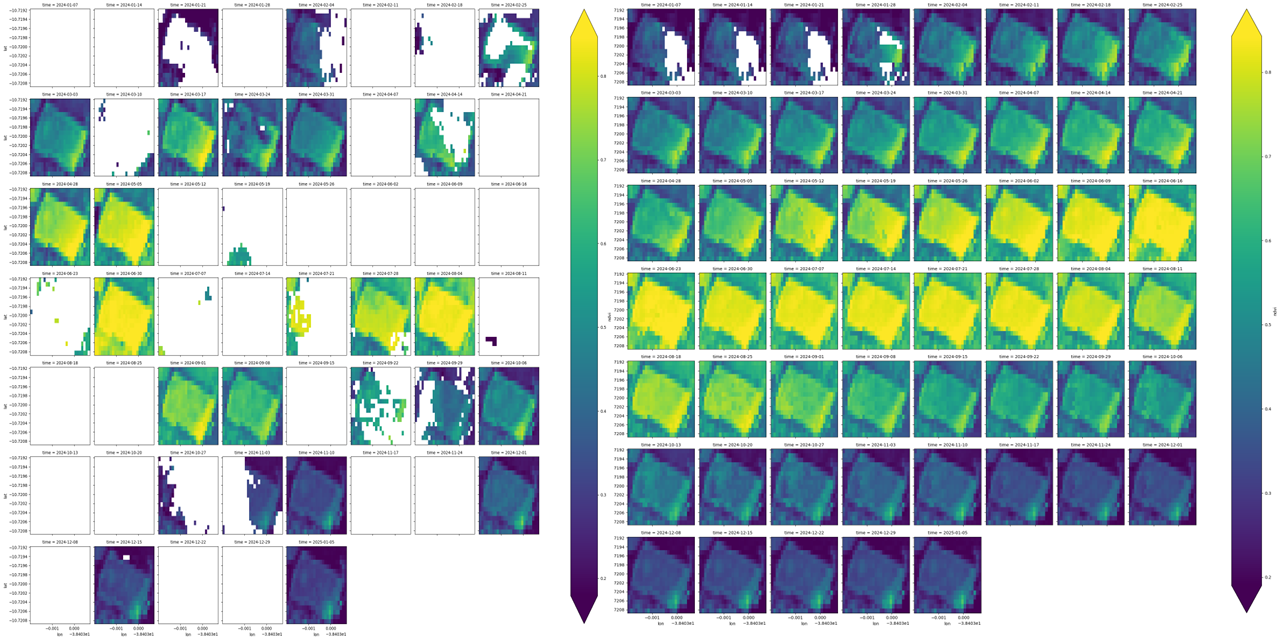